Augmented Data Visualization

In [1]:
import os
import glob
import pandas as pd
import xml.etree.ElementTree as ET
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import torch
from torchvision.transforms import v2
import numpy as np
from xml.dom import minidom

from segpaste.augmentation import CopyPasteAugmentation
from segpaste.config import CopyPasteConfig
from segpaste.types import DetectionTarget

def xml_to_df(path):
    """
    Convert all XML annotation files in a directory into a single pandas dataframe.
    """
    xml_list = []
    for xml_file in glob.glob(path + '/*.xml'):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        # Each object is a bounding box
        for member in root.findall('object'):
            value = (root.find('filename').text,               # image filename
                    int(root.find('size')[0].text),           # image width
                    int(root.find('size')[1].text),           # image height
                    member[0].text,                           # object class name
                    int(member[4][0].text),                   # xmin
                    int(member[4][1].text),                   # ymin
                    int(member[4][2].text),                   # xmax
                    int(member[4][3].text)                    # ymax
                    )
            xml_list.append(value)
    column_name = ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']
    xml_df = pd.DataFrame(xml_list, columns=column_name)
    return xml_df
    
def load_annotations(image_dir):
    """
    Load both the training and testing annotation directories.
    Returns: train_df, test_df
    """
    dfs = [] 
    for folder in ['train_annotations','test_annotations']:
        ann_path = os.path.join(image_dir, folder) # full path
        xml_df = xml_to_df(ann_path)
        dfs.append(xml_df)
    return dfs # train, test

def build_combined_df(train_df, test_df):
    """
    Combine train and test annotation dataframes into one.
    A 'split' column labels which dataset each row belongs to.
    """
    train = train_df.copy()
    test = test_df.copy()
    train["split"] = "train"
    test["split"] = "test"
    return pd.concat([train, test], ignore_index=True)

BASE_DIR = os.getcwd() # correct path only from this notebook's directory
image_dir = os.path.join(BASE_DIR, "augmented_images") # main data folder
train_ann, test_ann = load_annotations(image_dir) # load XMLs
combined_df = build_combined_df(train_ann, test_ann) # merge into one df

full_aug_dir = os.path.join(BASE_DIR, "full_augmented_dataset")

full_train, full_test = load_annotations(full_aug_dir)
full_combined_df = build_combined_df(full_train, full_test)


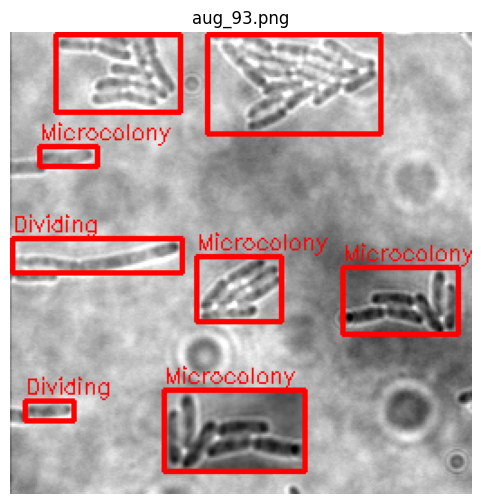

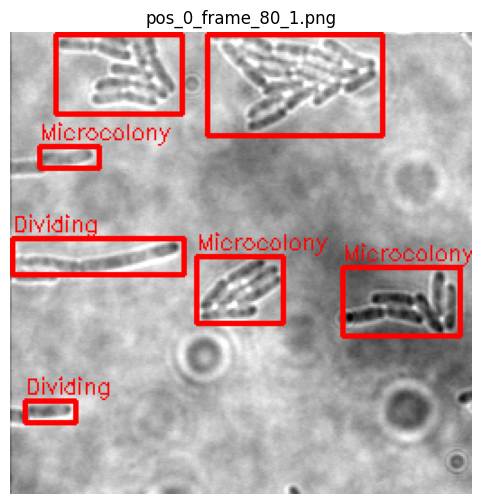

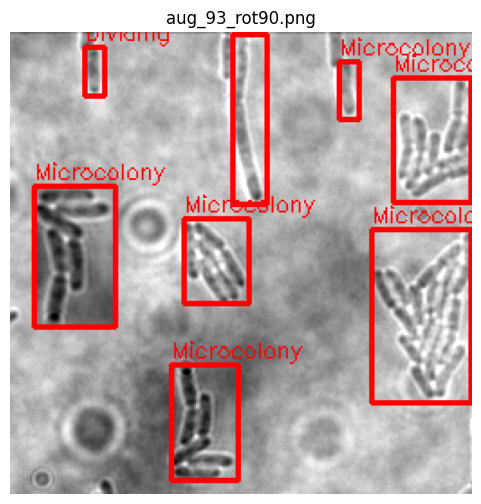

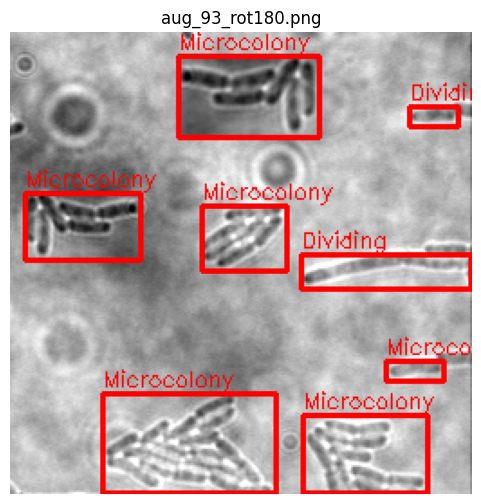

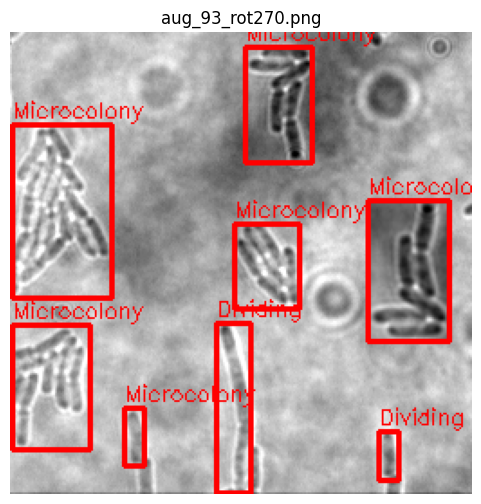

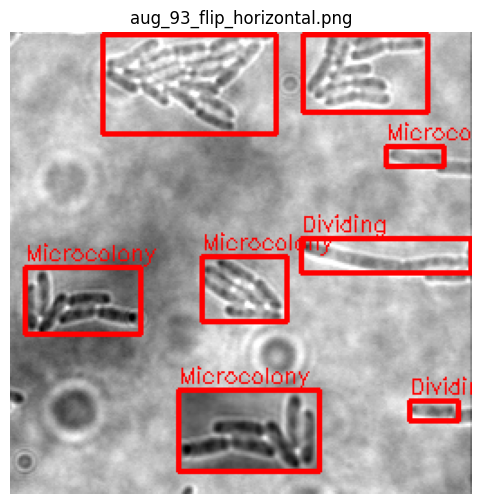

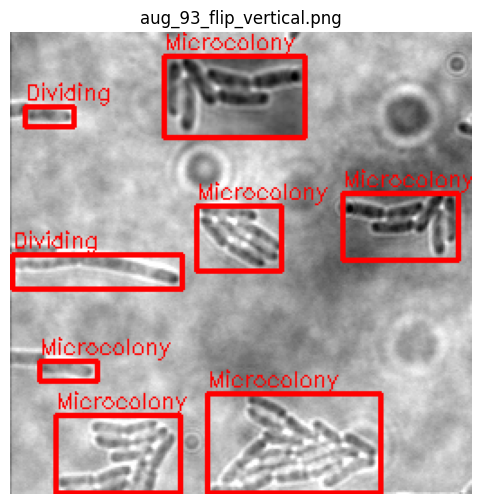

In [2]:
def show_image_with_boxes(df, image_dir, filename):
    """
    Show a single example image with all bounding box annotations drawn on it.
    """
    anns = df[df["filename"] == filename]    # all rows from a single file
    img_path = os.path.join(image_dir, filename)
    img = cv2.imread(img_path)    # load image
    if img is None:
        print("Image not found:", img_path)
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)    # convert to matplotlib RGB

    # draw boxes on the image
    for _, row in anns.iterrows():
        x1, y1, x2, y2 = int(row.xmin), int(row.ymin), int(row.xmax), int(row.ymax)
        label = row["class"]
        cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2) # draw box
        cv2.putText(img, label, (x1, y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,0,0), 1) # add label
        
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(filename)
    plt.show()
train_dir = os.path.join(image_dir, "train_images")
full_train_dir = os.path.join(full_aug_dir, "train_images")
show_image_with_boxes(train_ann, train_dir, "aug_93.png")
show_image_with_boxes(train_ann, train_dir, "pos_0_frame_80_1.png")
show_image_with_boxes(full_train, full_train_dir, "aug_93_rot90.png")
show_image_with_boxes(full_train, full_train_dir, "aug_93_rot180.png")
show_image_with_boxes(full_train, full_train_dir, "aug_93_rot270.png")
show_image_with_boxes(full_train, full_train_dir, "aug_93_flip_horizontal.png")
show_image_with_boxes(full_train, full_train_dir, "aug_93_flip_vertical.png")

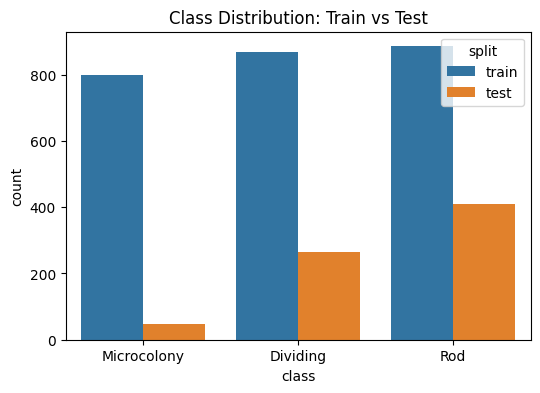

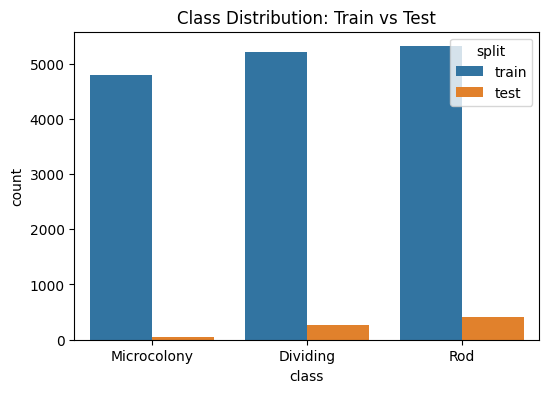

In [3]:
# Class distribution comparison

def plot_class_distributions(combined_df):
    plt.figure(figsize=(6,4))
    sns.countplot(data=combined_df, x="class", hue="split")
    plt.title("Class Distribution: Train vs Test")
    plt.show()

plot_class_distributions(combined_df)
plot_class_distributions(full_combined_df)

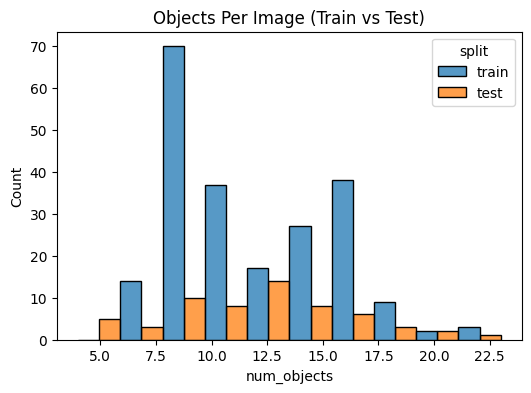

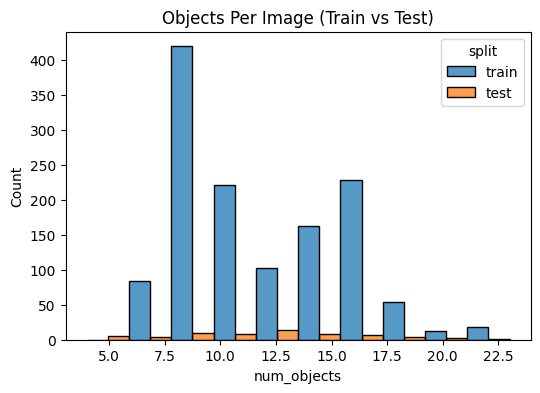

In [4]:
# Objects per image comparison

def plot_objects_per_image(combined_df):
    counts = combined_df.groupby(["split", "filename"]).size().reset_index(name="num_objects")

    plt.figure(figsize=(6,4))
    sns.histplot(data=counts, x="num_objects", hue="split", hue_order=["train", "test"], bins=10, multiple="dodge")
    plt.title("Objects Per Image (Train vs Test)")
    plt.show()
    
plot_objects_per_image(combined_df)
plot_objects_per_image(full_combined_df)



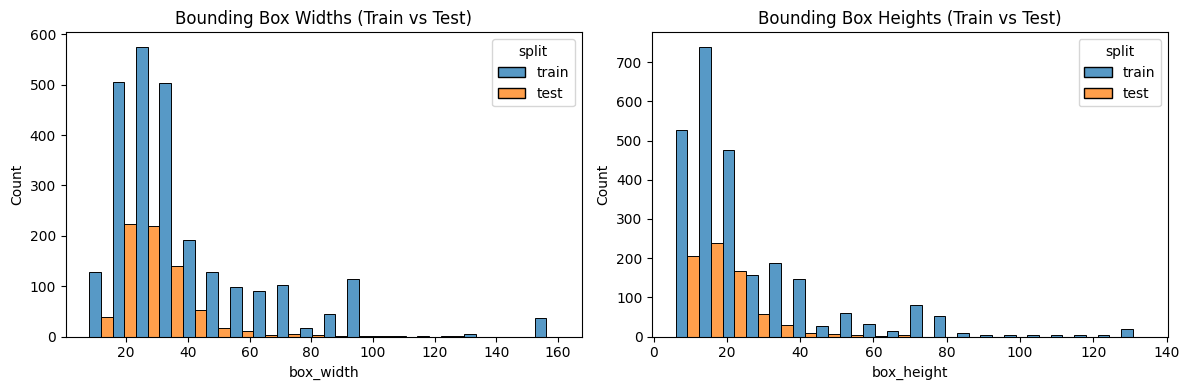

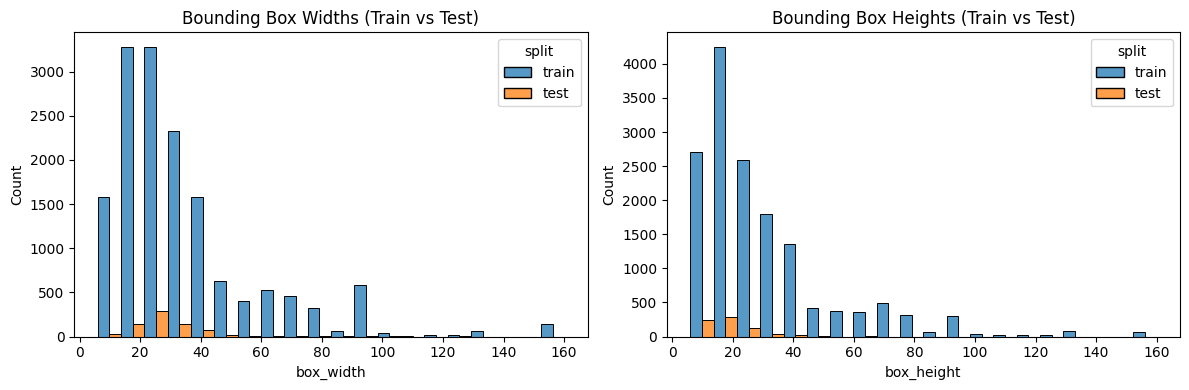

In [5]:
def plot_box_sizes(combined_df):
    df = combined_df.copy()
    df["box_width"] = df["xmax"] - df["xmin"]
    df["box_height"] = df["ymax"] - df["ymin"]

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    sns.histplot(data=df, x="box_width", hue="split", bins=20, ax=axes[0], multiple="dodge")
    axes[0].set_title("Bounding Box Widths (Train vs Test)")

    sns.histplot(data=df, x="box_height", hue="split", bins=20, ax=axes[1], multiple="dodge")
    axes[1].set_title("Bounding Box Heights (Train vs Test)")

    plt.tight_layout()
    plt.show()

plot_box_sizes(combined_df)
plot_box_sizes(full_combined_df)

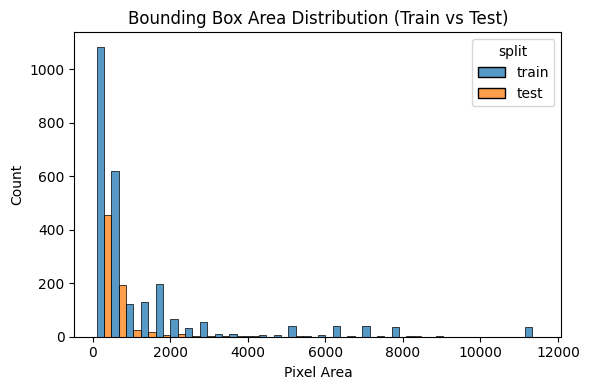

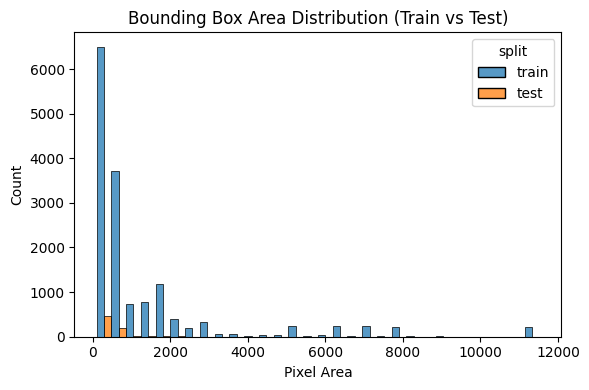

In [6]:
# Box area comparison

def plot_box_area(combined_df):
    df = combined_df.copy()
    df["area"] = (df["xmax"] - df["xmin"]) * (df["ymax"] - df["ymin"])

    plt.figure(figsize=(6,4))
    sns.histplot(
        data=df, x="area", hue="split",
        bins=30, multiple="dodge"
    )
    plt.title("Bounding Box Area Distribution (Train vs Test)")
    plt.xlabel("Pixel Area")
    plt.tight_layout()
    plt.show()
plot_box_area(combined_df)
plot_box_area(full_combined_df)